# 1. 다양한 영상 5장에 대해 ResNet50 활용해 실험 수행

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

[이미지: bike.jpg] 예측 결과
- mountain_bike (n03792782): 0.6002
- bicycle-built-for-two (n02835271): 0.2813
- disk_brake (n03208938): 0.0983


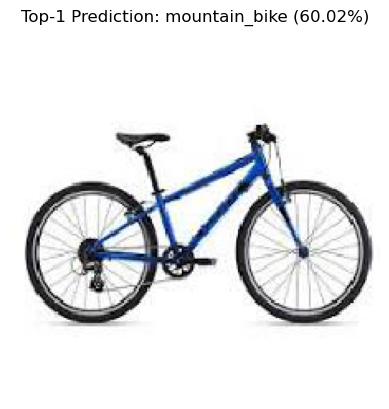

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

[이미지: bird.jpg] 예측 결과
- vulture (n01616318): 0.2640
- hummingbird (n01833805): 0.2270
- kite (n01608432): 0.0806


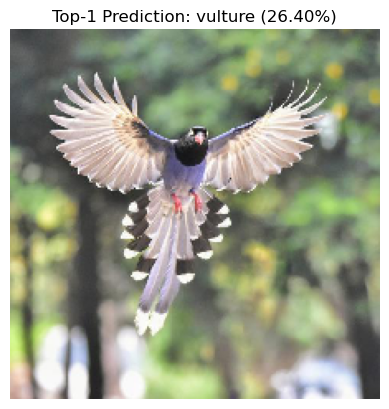

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

[이미지: bus.jpg] 예측 결과
- trolleybus (n04487081): 0.4322
- passenger_car (n03895866): 0.4258
- minibus (n03769881): 0.1296


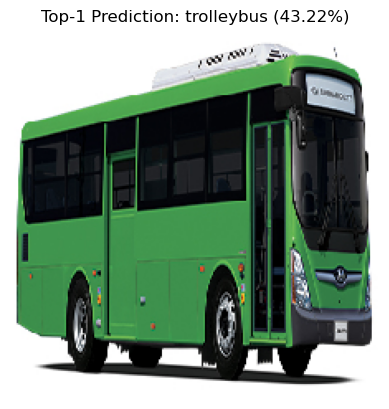

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

[이미지: car.jpg] 예측 결과
- car_wheel (n02974003): 0.3282
- sports_car (n04285008): 0.3209
- cab (n02930766): 0.1678


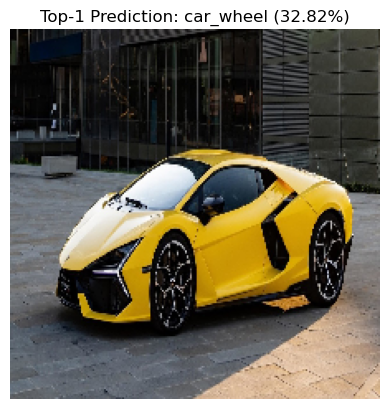

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step

[이미지: elephant.jpg] 예측 결과
- tusker (n01871265): 0.5395
- Indian_elephant (n02504013): 0.3150
- African_elephant (n02504458): 0.1455


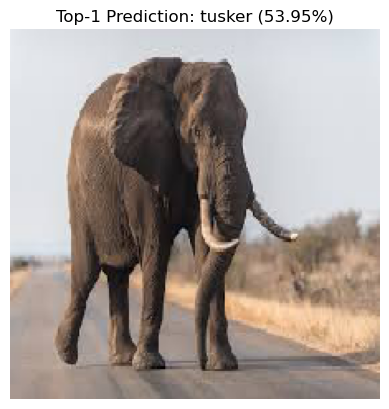

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

[이미지: food.jpg] 예측 결과
- coral_reef (n09256479): 0.5508
- grocery_store (n03461385): 0.1404
- fig (n07753113): 0.0578


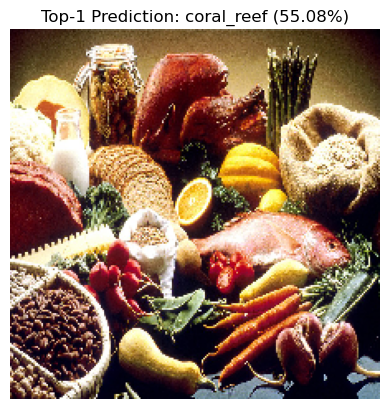

In [14]:
# 73페이지 인식 프로그램 호출

from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import os

# 모델 로드 (ImageNet으로 학습된 ResNet50)
model = ResNet50(weights='imagenet')

# 예측할 이미지들이 있는 경로 설정
img_dir = 'imgs'  # 사용자 이미지 5장 경로
img_names = sorted(os.listdir(img_dir))[:6]  

# 예측 및 시각화
for fname in img_names:
    img_path = os.path.join(img_dir, fname)
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    preds = model.predict(x)
    decoded = decode_predictions(preds, top=3)[0]

    # 결과 출력
    print(f"\n[이미지: {fname}] 예측 결과")
    for label, desc, score in decoded:
        print(f"- {desc} ({label}): {score:.4f}")

    # 시각화
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Top-1 Prediction: {decoded[0][1]} ({decoded[0][2]*100:.2f}%)')
    plt.show()



In [ ]:
# 74페이지 특징 추출 부분 호출

from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing import image
import numpy as np
import os

# ResNet50 모델 로드 (최상위 FC층은 포함하지 않음 → 특징 추출용)
model = ResNet50(weights='imagenet', include_top=False)

# 이미지 경로 설정
img_dir = 'imgs'  # 사용자 이미지 폴더
img_names = sorted(os.listdir(img_dir))[:6]  # 상위 6장만 사용

# 이미지별 특징 추출
for fname in img_names:
    img_path = os.path.join(img_dir, fname)
    img = image.load_img(img_path, target_size=(224, 224))  
    x = image.img_to_array(img)                              
    x = np.expand_dims(x, axis=0)                            
    x = preprocess_input(x)                                  

    features = model.predict(x)  # CNN 중간 계층 결과 추출
    print(f"\n[이미지: {fname}] 추출된 feature shape: {features.shape}")



1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

[이미지: bike.jpg] 추출된 feature shape: (1, 7, 7, 2048)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step

[이미지: bird.jpg] 추출된 feature shape: (1, 7, 7, 2048)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

[이미지: bus.jpg] 추출된 feature shape: (1, 7, 7, 2048)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step

[이미지: car.jpg] 추출된 feature shape: (1, 7, 7, 2048)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

[이미지: elephant.jpg] 추출된 feature shape: (1, 7, 7, 2048)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

[이미지: food.jpg] 추출된 feature shape: (1, 7, 7, 2048)


---

# 2. ResNet50 구조 및 파라미터 결과

In [15]:
from tensorflow.keras.applications import ResNet50

# 모델 로드 (ImageNet 학습된 가중치, 최상위 포함)
model = ResNet50(weights='imagenet', include_top=True, input_shape=(224, 224, 3))

# 모델 구조 및 파라미터 수 출력
model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_14[0… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

## ResNet50 모델 구조 요약

| 항목 | 설명 |
| --- | --- |
| **총 파라미터 수** | **25,636,712**개 (약 **25.6M**) |
| **Trainable Parameters** | 25,583,592개 (대부분 학습 가능) |
| **Non-trainable Parameters** | 53,120개 (주로 BatchNorm의 평균/분산 같은 정적 값) |
| **입력 크기** | `(None, 224, 224, 3)` (RGB 이미지) |
| **출력 크기** | `(None, 1000)` (ImageNet 클래스 수 기준) |
| **최상위 레이어** | `GlobalAveragePooling` → `Dense(1000)` |
| **중간 구조 특징** | 총 **5개 stage**, 각 stage마다 **Residual Block(잔차 블록)** 반복 구성 |

## 블록 구성 요약 (계층별 반복 구조)

| Stage | 블록 수 | 특징 | 출력 Feature Map |
| --- | --- | --- | --- |
| **Stage 1** | 1 Conv + MaxPool | 기본 처리 | (112, 112, 64) → (56, 56, 64) |
| **Stage 2** | 3 Residual Blocks | Conv2_x | (56, 56, 256) |
| **Stage 3** | 4 Residual Blocks | Conv3_x | (28, 28, 512) |
| **Stage 4** | 6 Residual Blocks | Conv4_x | (14, 14, 1024) |
| **Stage 5** | 3 Residual Blocks | Conv5_x | (7, 7, 2048) |
| **끝단** | GAP + FC(1000) | ImageNet 클래스 예측 |  |

---

# 3. ResNet50으로 cats_and_dogs_small 학습 재구성

In [17]:
# ResNet50 모델 불러오기

from tensorflow.keras.applications import ResNet50

conv_base = ResNet50(
    weights='imagenet',
    include_top=False,                # 최상위 FC 제거
    input_shape=(150, 150, 3)
)

conv_base


<Functional name=resnet50, built=True>

In [18]:
# 데이터 전처리 설정

import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 경로 설정
base_dir = 'cats_and_dogs_small'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

# 리스케일링만 적용
datagen = ImageDataGenerator(rescale=1. / 255)
batch_size = 20

In [ ]:
# ResNet50의 특징 벡터 추출 함수

def extract_features(directory, sample_count):
    features = np.zeros(shape=(sample_count, 5, 5, 2048))  # ResNet50은 (5,5,2048) 출력
    labels = np.zeros(shape=(sample_count))
    generator = datagen.flow_from_directory( # 데이터 읽기
        directory,
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary'
    )
    i = 0
    for inputs_batch, labels_batch in generator:
        features_batch = conv_base.predict(inputs_batch) # ResNet50으로 특징 추출
        features[i * batch_size: (i + 1) * batch_size] = features_batch
        labels[i * batch_size: (i + 1) * batch_size] = labels_batch
        i += 1
        if i * batch_size >= sample_count:
            break
    return features, labels

# 특징 추출
train_features, train_labels = extract_features(train_dir, 2000)
validation_features, validation_labels = extract_features(validation_dir, 1000)
test_features, test_labels = extract_features(test_dir, 1000)


In [ ]:
# FC 층 설계 및 학습

from tensorflow.keras import models, layers, optimizers

# Reshape
train_features = np.reshape(train_features, (2000, 5 * 5 * 2048))
validation_features = np.reshape(validation_features, (1000, 5 * 5 * 2048))
test_features = np.reshape(test_features, (1000, 5 * 5 * 2048))

# FC 구조
model = models.Sequential()
model.add(layers.Dense(256, activation='relu', input_dim=5 * 5 * 2048))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(1, activation='sigmoid'))

# 컴파일 및 학습
model.compile(
    optimizer=optimizers.RMSprop(learning_rate=2e-5),
    loss='binary_crossentropy',
    metrics=['acc']
)

history = model.fit(
    train_features, train_labels,
    epochs=20,
    batch_size=20,
    validation_data=(validation_features, validation_labels)
)

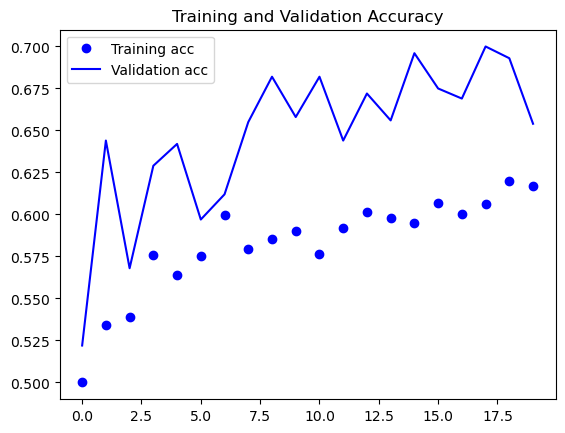

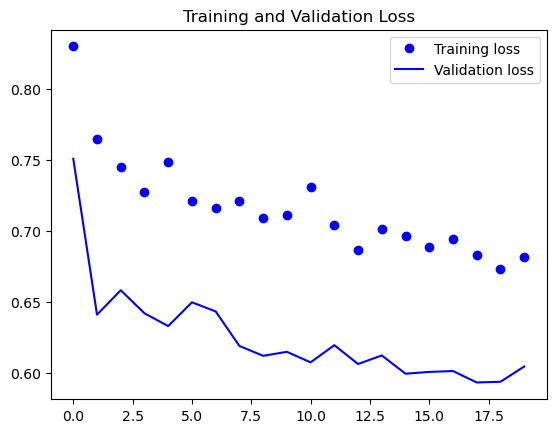

In [21]:
# 정확도/손실 시각화

import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


---

# 4단계. VGG16 vs ResNet50 구조와 파라미터 수 비교 및 최상위 레이어 제거 시 결과 설명 

In [28]:
from keras.applications import VGG16

# VGG16 모델 로드
conv_base = VGG16(
    weights='imagenet',
    include_top=True,
)

conv_base.summary()


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_22 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
from keras.applications import VGG16

# VGG16 모델 로드
conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)

conv_base.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

## 최상위 레이어 유무에 따른 결과 차이

| 항목 | `include_top=True` | `include_top=False` |
| --- | --- | --- |
| 사용 목적 | 바로 분류 (예: ImageNet 1000 클래스) | 전이학습용 feature extractor |
| 최상위 FC 레이어 포함 여부 | 포함됨 (`Flatten → Dense(4096) × 2 → Dense(1000)`) | 포함 안 됨 |
| 출력 shape | `(None, 1000)` | `(None, 4, 4, 512)` (입력 크기에 따라 달라짐) |
| 파라미터 수 | 약 **138M** | 약 **14.7M** (FC 파트 제외) |
| 대표 용도 | 사전학습된 모델을 그대로 예측에 사용 | 하위 CNN만 사용하고 FC를 새로 정의해 fine-tuning |
| 학습 가능 여부 | 전체 학습 가능 (무겁고 느림) | 상위 FC만 학습 (가볍고 빠름) |

In [29]:
from keras.applications import ResNet50

# ResNet50 모델 로드
conv_base = ResNet50(
    weights='imagenet',
    include_top=True,
)

conv_base.summary()


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_23      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_23[0… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [23]:
from keras.applications import ResNet50

# ResNet50 모델 로드
conv_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)

conv_base.summary()


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_19      │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 156, 156,  │          0 │ input_layer_19[0… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 75, 75,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 75, 75,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 75, 75,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 77, 77,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 38, 38,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 38, 38,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 38, 38,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 38, 38,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 38, 38,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 38, 38,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 38, 38,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 38, 38,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 38, 38,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 38, 38,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 38, 38,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

## 최상위 레이어 유무에 따른 결과 차이

| 항목 | `include_top=True` | `include_top=False` |
| --- | --- | --- |
| **사용 목적** | 바로 분류 (예: ImageNet 1000 클래스) | 전이학습용 feature extractor |
| **최상위 FC 레이어 포함 여부** | 포함됨 (`GlobalAveragePooling → Dense(1000)`) | 포함 안 됨 |
| **출력 shape** | `(None, 1000)` | `(None, 7, 7, 2048)` *(입력 224×224 기준)* |
| **파라미터 수** | 약 **25.6M** | 약 **23.6M** |
| **대표 용도** | 사전학습된 모델 그대로 예측에 사용 | CNN 부분만 사용하고 FC를 새로 정의해 fine-tuning |
| **학습 가능 여부** | 전체 학습 가능 (FC까지 포함, 상대적으로 무거움) | 상위 FC만 학습 (효율적이고 가벼움) |

## VGG16 vs ResNet50 모델 구조 및 파라미터 수 비교

### 1. 모델 구조 비교

| 항목 | VGG16 | ResNet50 |
| --- | --- | --- |
| 등장년도 | 2014 (VGG팀, ILSVRC 우승) | 2015 (Microsoft Research) |
| 구조 타입 | 순차적(계단식) Conv + FC | Residual Block (Skip Connection) |
| 총 레이어 수 | 16 | 50 |
| 주된 구성 | Conv(3×3), MaxPool, FC | Conv(1×1, 3×3), Identity Block, GAP |
| skip connection | 없음 | 있음 |
| overfitting 대응 | 없음 (Dropout 필요) | 구조적으로 완화 |

### 2. 파라미터 수 비교

| 구성 | VGG16 (include_top=True) | ResNet50 (include_top=True) |
| --- | --- | --- |
| 입력 크기 | (224, 224, 3) | (224, 224, 3) |
| 최상위 구조 | FC(4096×3), softmax | GAP → Dense(1000) |
| 전체 파라미터 | **약 138M** | **약 25.6M** |
| 훈련 가능 파라미터 | 대부분 가능 | 대부분 가능 |